In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Model imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns',200)
%matplotlib inline

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
#Loading the data
path="data/For_modeling.csv.zip"

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
data = pd.read_csv(path, 
                  dtype={
                      'Duration': 'int8',
                      'Distance': 'int8',
                      'PLong': 'float32',
                      'PLatd': 'float32',
                      'DLong': 'float32',
                      'Haversine':'float32',
                      'Pmonth':'int8',
                      'Pday':'int8',
                      'Phour':'int8',
                      'Pmin':'int8',
                      'PDweek':'int8',
                      'Dmonth':'int8',
                      'Dday':'int8',
                      'Dhour':'int8',
                      'Dmin':'int8',
                      'DDweek':'int8',
                      'Temp':'float32',
                      'Precip':'float32',
                      'Wind':'float32',
                      'Solar':'float32',
                      'Snow':'float32',
                      'GroundTemp':'float32',
                      'Dust':'float32'
                  },index_col=0
                  
                  ).sample(frac=1)

#checking for data
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
485865,49,-22,37.575493,126.978500,37.575493,126.978500,0.000000,3,14,12,18,2,3,14,13,8,2,19.900000,0.0,2.7,44.0,2.22,0.0,23.500000,42.0
5885583,11,4,37.593288,127.036667,37.603043,127.033272,1.125190,9,7,19,53,4,9,7,20,4,4,22.600000,0.0,2.8,39.0,0.14,0.0,21.200001,13.0
7057807,22,-78,37.539501,127.083000,37.562527,127.082275,2.561176,10,2,0,16,1,10,2,0,40,1,13.000000,0.0,1.8,72.0,0.00,0.0,12.200000,16.0
2726990,91,-76,37.481239,127.119797,37.480576,127.118568,0.131132,6,9,13,28,5,6,9,15,3,5,28.799999,0.0,2.0,42.0,2.38,0.0,50.400002,32.0
7058583,32,-18,37.546547,127.106133,37.607349,127.078590,7.183391,10,2,0,41,1,10,2,1,13,1,13.000000,0.0,1.8,72.0,0.00,0.0,12.200000,16.0
740128,24,-122,37.526989,126.932098,37.513359,126.948059,2.068451,3,30,17,53,4,3,30,18,17,4,19.400000,0.0,2.9,45.0,1.13,0.0,20.900000,76.0
6318140,20,38,37.575802,126.890739,37.600700,126.920128,3.790846,9,15,23,56,5,9,16,0,18,6,22.900000,0.0,0.9,81.0,0.00,0.0,21.700001,14.0
6509048,40,-60,37.552746,126.918617,37.509720,126.890099,5.404919,9,20,18,15,3,9,20,18,56,3,19.100000,0.0,2.5,77.0,0.08,0.0,19.100000,8.0
1884128,66,96,37.551567,126.902847,37.551567,126.902847,0.000000,5,16,0,1,2,5,16,1,8,2,24.400000,0.0,0.8,63.0,0.00,0.0,21.700001,40.0
3390411,18,48,37.469200,127.029007,37.477852,127.038910,1.299731,6,27,11,21,2,6,27,11,40,2,23.400000,0.0,1.3,73.0,2.38,0.0,31.200001,32.0


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
#Resetting index
data = data.reset_index().drop(columns=['index'])
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
0,49,-22,37.575493,126.978500,37.575493,126.978500,0.000000,3,14,12,18,2,3,14,13,8,2,19.900000,0.0,2.7,44.0,2.22,0.0,23.500000,42.0
1,11,4,37.593288,127.036667,37.603043,127.033272,1.125190,9,7,19,53,4,9,7,20,4,4,22.600000,0.0,2.8,39.0,0.14,0.0,21.200001,13.0
2,22,-78,37.539501,127.083000,37.562527,127.082275,2.561176,10,2,0,16,1,10,2,0,40,1,13.000000,0.0,1.8,72.0,0.00,0.0,12.200000,16.0
3,91,-76,37.481239,127.119797,37.480576,127.118568,0.131132,6,9,13,28,5,6,9,15,3,5,28.799999,0.0,2.0,42.0,2.38,0.0,50.400002,32.0
4,32,-18,37.546547,127.106133,37.607349,127.078590,7.183391,10,2,0,41,1,10,2,1,13,1,13.000000,0.0,1.8,72.0,0.00,0.0,12.200000,16.0
5,24,-122,37.526989,126.932098,37.513359,126.948059,2.068451,3,30,17,53,4,3,30,18,17,4,19.400000,0.0,2.9,45.0,1.13,0.0,20.900000,76.0
6,20,38,37.575802,126.890739,37.600700,126.920128,3.790846,9,15,23,56,5,9,16,0,18,6,22.900000,0.0,0.9,81.0,0.00,0.0,21.700001,14.0
7,40,-60,37.552746,126.918617,37.509720,126.890099,5.404919,9,20,18,15,3,9,20,18,56,3,19.100000,0.0,2.5,77.0,0.08,0.0,19.100000,8.0
8,66,96,37.551567,126.902847,37.551567,126.902847,0.000000,5,16,0,1,2,5,16,1,8,2,24.400000,0.0,0.8,63.0,0.00,0.0,21.700001,40.0
9,18,48,37.469200,127.029007,37.477852,127.038910,1.299731,6,27,11,21,2,6,27,11,40,2,23.400000,0.0,1.3,73.0,2.38,0.0,31.200001,32.0


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#Dropping value with haversine ==0
data= data[data['Haversine']!=0].reset_index().drop(columns=['index'])
#data.shape

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
#transforming all the negative distance to posiive distances

data["Distance"]=data['Distance'].apply(lambda x:abs(x))
data[data['Distance']<0].shape

(0, 25)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
#Dropping values with diatance is zero, that indicate trip was never occured or error in recordings or something
data = data[data['Distance']!=0].reset_index().drop(columns=['index'])
data[data['Distance']==0].shape

(0, 25)

<ipython-input-8-8c83b0d3aa80>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_duration = data.groupby(data1)['Duration'].mean()


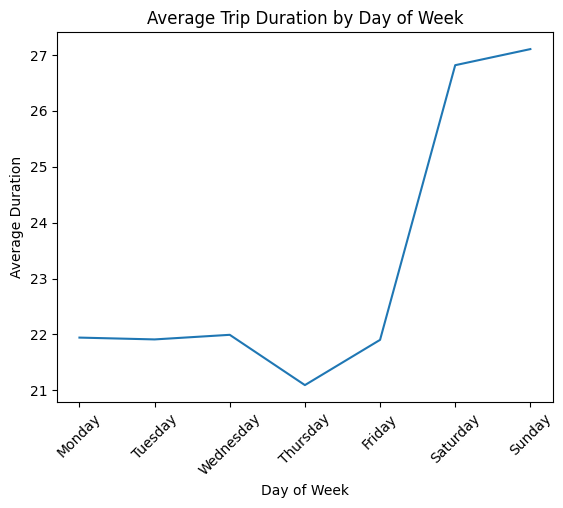

In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# === BEFORE (original) ===
# #Average Trip Duration by Day of Week
# # Convert the 'PDweek' column to a day of the week name
# data1= pd.Categorical(data['PDweek'], categories=range(7), ordered=True)
# data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], inplace=True)
# 
# # Calculate the average trip duration for each day of the week
# average_duration = data1.groupby('DayOfWeek')['Duration'].mean()
# 
# # Create a line chart
# plt.plot(average_duration.index, average_duration.values)
# plt.xlabel('Day of Week')
# plt.ylabel('Average Duration')
# plt.title('Average Trip Duration by Day of Week')
# plt.xticks(rotation=45)
# plt.show()

# === AFTER (edited) ===
data1 = pd.Series(pd.Categorical(data['PDweek'], categories=range(7), ordered=True))
data1 = data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

average_duration = data.groupby(data1)['Duration'].mean()

plt.plot(average_duration.index, average_duration.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Duration')
plt.title('Average Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Behavioral test for day-of-week aggregation fix
expected_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
assert 'DayOfWeek' in data.columns, 'Expected DayOfWeek column to be created on data'
assert str(data['DayOfWeek'].dtype) == 'category', 'DayOfWeek should be categorical'
assert list(data['DayOfWeek'].cat.categories) == expected_days, 'DayOfWeek categories should be renamed to weekday names'
assert average_duration.index.name == 'DayOfWeek', 'Aggregation should group by DayOfWeek on data'
assert len(average_duration) == 7, 'Expected one aggregated value per weekday'

AssertionError: Expected DayOfWeek column to be created on data